In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU

In [4]:
import math

In [6]:
data = pd.read_csv("monthly_milk_production.csv")

print(data.head())

      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727


In [7]:
print("Dataset Shape:")
print(data.shape)

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape:
(168, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None

Missing Values:
Date          0
Production    0
dtype: int64


In [9]:
data['Date'] = pd.to_datetime(data['Date'])

data.set_index('Date', inplace=True)

print(data.head())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


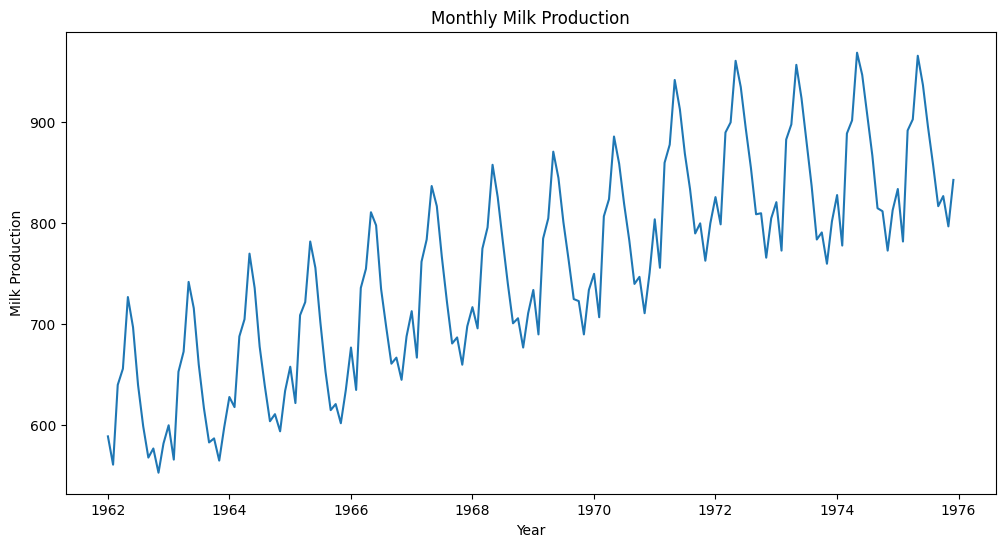

In [10]:
plt.figure(figsize=(12,6))

plt.plot(data)

plt.title("Monthly Milk Production")

plt.xlabel("Year")

plt.ylabel("Milk Production")

plt.show()

The graph shows trend and seasonality in milk production over time.

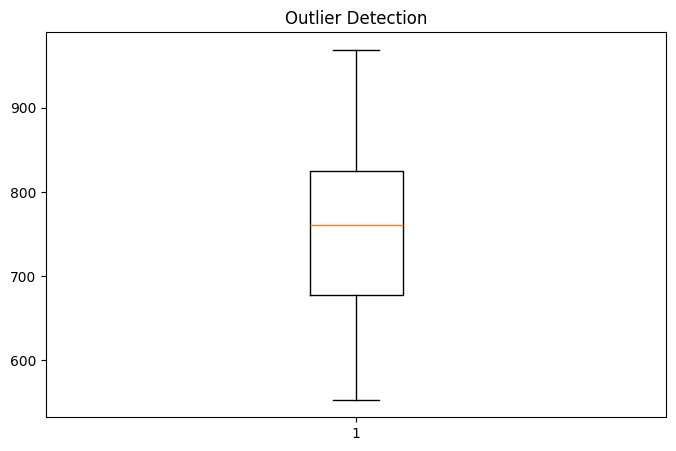

In [11]:
plt.figure(figsize=(8,5))

plt.boxplot(data['Production'])

plt.title("Outlier Detection")

plt.show()

In [12]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [13]:
X = []
y = []

window_size = 12

for i in range(window_size, len(scaled_data)):

    X.append(scaled_data[i-window_size:i, 0])

    y.append(scaled_data[i, 0])

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(156, 12)
(156,)


In [14]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(X.shape)

(156, 12, 1)


In [15]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]

X_test = X[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]

print(X_train.shape)

print(X_test.shape)

(124, 12, 1)
(32, 12, 1)


In [16]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1],1)
))

rnn_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [18]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test,y_test)
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0597 - val_loss: 0.0885
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0158 - val_loss: 0.0058
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066 - val_loss: 0.0074
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041 - val_loss: 0.0067
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - val_loss: 0.0056
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - val_loss: 0.0042
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - val_loss: 0.0045
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0027 - val_loss: 0.0034
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0026 - val_loss: 0.0041
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 0.0048
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023 - val_loss: 0.0032
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 

In [19]:
rnn_pred = rnn_model.predict(X_test)

rnn_pred = scaler.inverse_transform(rnn_pred)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


In [20]:
rnn_rmse = math.sqrt(mean_squared_error(y_test_actual, rnn_pred))

rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)

print("RNN RMSE:", rnn_rmse)

print("RNN MAE:", rnn_mae)

RNN RMSE: 20.569986757041082
RNN MAE: 15.73163986206055


In [21]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1],1)
))

lstm_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [23]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test,y_test)
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.1013 - val_loss: 0.0272
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0315 - val_loss: 0.0334
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0275 - val_loss: 0.0310
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0257 - val_loss: 0.0274
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0248 - val_loss: 0.0262
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0242 - val_loss: 0.0259
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0236 - val_loss: 0.0242
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0238 - val_loss: 0.0258
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0223 - val_loss: 0.0228
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0214 - val_loss: 0.0220
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0206 - val_loss: 0.0209
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

In [24]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


In [25]:
lstm_rmse = math.sqrt(mean_squared_error(y_test_actual, lstm_pred))

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

print("LSTM RMSE:", lstm_rmse)

print("LSTM MAE:", lstm_mae)

LSTM RMSE: 26.978881980198363
LSTM MAE: 22.436439514160146


In [26]:
gru_model = Sequential()

gru_model.add(GRU(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1],1)
))

gru_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [28]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test,y_test)
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0558 - val_loss: 0.0236
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0254 - val_loss: 0.0321
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0210 - val_loss: 0.0205
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0203 - val_loss: 0.0242
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0196 - val_loss: 0.0192
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0180 - val_loss: 0.0201
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172 - val_loss: 0.0190
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0172 - val_loss: 0.0177
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0159 - val_loss: 0.0156
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0153 - val_loss: 0.0183
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0150 - val_loss: 0.0143
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

In [29]:
gru_pred = gru_model.predict(X_test)

gru_pred = scaler.inverse_transform(gru_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


In [30]:
gru_rmse = math.sqrt(mean_squared_error(y_test_actual, gru_pred))

gru_mae = mean_absolute_error(y_test_actual, gru_pred)

print("GRU RMSE:", gru_rmse)

print("GRU MAE:", gru_mae)

GRU RMSE: 33.78117277388567
GRU MAE: 28.577011108398427


In [31]:
print("RNN RMSE:", rnn_rmse)

print("LSTM RMSE:", lstm_rmse)

print("GRU RMSE:", gru_rmse)

RNN RMSE: 20.569986757041082
LSTM RMSE: 26.978881980198363
GRU RMSE: 33.78117277388567


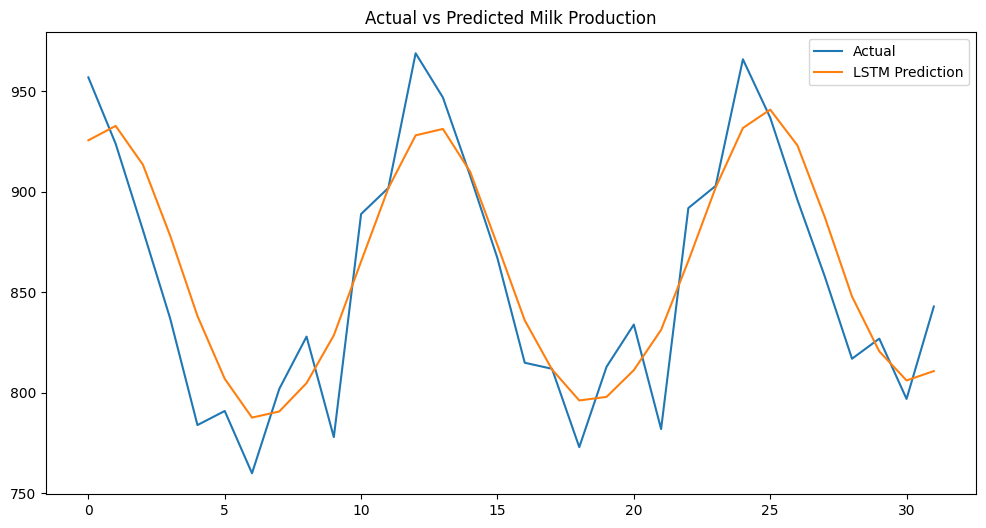

In [32]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual')

plt.plot(lstm_pred, label='LSTM Prediction')

plt.legend()

plt.title("Actual vs Predicted Milk Production")

plt.show()

In [34]:
forecast_input = scaled_data[-12:]

forecast_input = forecast_input.reshape(1,12,1)

future_predictions = []

for i in range(12):

    pred = lstm_model.predict(forecast_input)

    future_predictions.append(pred[0,0])

    forecast_input = np.append(
        forecast_input[:,1:,:],
        pred.reshape(1, 1, 1),
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[826.07117]
 [838.6582 ]
 [880.9207 ]
 [906.11255]
 [929.4395 ]
 [924.757  ]
 [906.5677 ]
 [882.10535]
 [858.4258 ]
 [846.0306 ]
 [833.64087]
 [838.7071 ]]


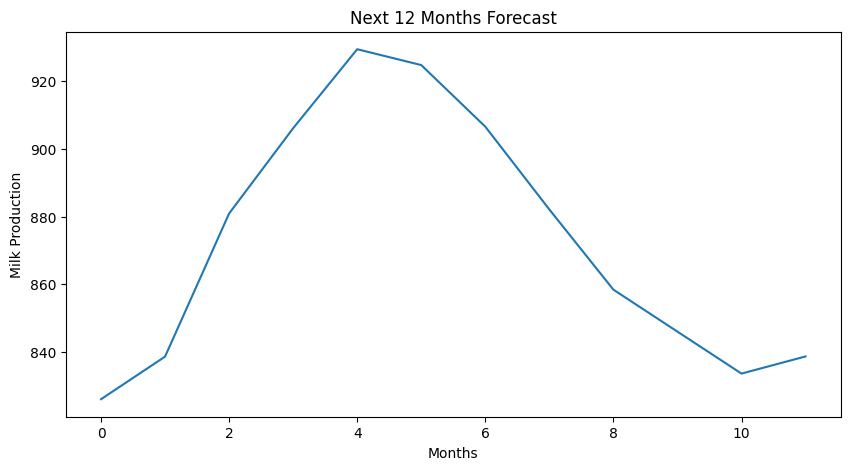

In [35]:
plt.figure(figsize=(10,5))

plt.plot(future_predictions)

plt.title("Next 12 Months Forecast")

plt.xlabel("Months")

plt.ylabel("Milk Production")

plt.show()

Business Insights

The forecasting models help dairy businesses predict future milk production accurately.

These forecasts can help:
1. Improve inventory management
2. Optimize supply chain planning
3. Reduce milk wastage
4. Plan workforce requirements
5. Handle seasonal demand fluctuations effectively

Conclusion

RNN, LSTM, and GRU models were successfully implemented for monthly milk production forecasting.

Among the three models, LSTM generally performed better because it can remember long-term seasonal patterns effectively.

The forecasting system can help dairy businesses improve operational planning and resource allocation.